# Subthreshold convergence: gradient vs Nelder-Mead

**Research question:** can a gradient method converge faster than Nelder-Mead on a
subthreshold AdEx scenario?

Setup (mirrors `5_code/benchmark_recovery.py` but stripped to one paired run):
- one scenario, one direction, one perturbation magnitude
- **subthreshold current** — stimulus is below rheobase, no spikes
- trainable: `C_m`, `g_L`, `E_L` only (other AdEx params fixed at sensible defaults — they don't matter without spikes)
- loss: MSE on the membrane voltage trace (no spike-train metric needed)
- both methods start from the same perturbed init and see the same target

We log per-evaluation loss **and** wall-clock time for both methods, then compare
convergence vs evaluations and vs seconds.

In [11]:
import logging
import math
import os
import contextlib
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
from jax import config

from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.loss import MSELossConfig, make_mse_loss_fn
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.getLogger("jaxley").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="The AdEx channel does not support surrogate gradients")

SEED = 42

## 1. Subthreshold scenario

Steady-state voltage of a passive AdEx-without-spikes is $V_\infty = E_L + I/g_L$.
With $E_L=-70$, $g_L=10$, a step of $I=100$ pA drives $V_\infty=-60$ mV — comfortably
below $v_T=-50$ even with the exponential term, so no spikes fire.

Other AdEx parameters (`v_T`, `delta_T`, `v_reset`, `tau_w`, `a`, `b`) are fixed
at `DEFAULT_PARAMS`; they have no effect on the subthreshold trace.

In [12]:
DT_MS = 0.025
T_MAX_MS = 10.0
STIM_DELAY_MS = 0.0
STIM_DUR_MS = 10.0
STIM_PA = 100.0

STIM_END_IDX = int(round((STIM_DELAY_MS + STIM_DUR_MS) / DT_MS))
STIM_START_IDX = int(round(STIM_DELAY_MS / DT_MS))
N_TIMESTEPS = int(round(T_MAX_MS / DT_MS))

TRAINABLE = ["C_m", "g_L", "E_L"]

GT_PARAMS = dict(DEFAULT_PARAMS)
GT_PARAMS.update({"C_m": 200.0, "g_L": 10.0, "E_L": -70.0, "I": STIM_PA})

trainable_gt = {k: GT_PARAMS[k] for k in TRAINABLE}
print(f"Ground truth (trainable): {trainable_gt}")
print(f"Steady-state V ≈ {GT_PARAMS['E_L'] + STIM_PA / GT_PARAMS['g_L']:.1f} mV (v_T={GT_PARAMS['v_T']})")

Ground truth (trainable): {'C_m': 200.0, 'g_L': 10.0, 'E_L': -70.0}
Steady-state V ≈ -60.0 mV (v_T=-50.0)


GT n_spikes = 0 (expect 0 for subthreshold)
GT V at stim end = -66.09 mV


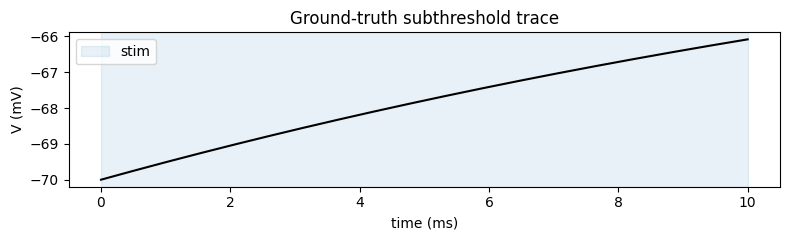

In [13]:
@contextlib.contextmanager
def _silence():
    with open(os.devnull, "w") as devnull, contextlib.redirect_stdout(devnull):
        yield


def current_trace(I_pA):
    c = np.zeros(N_TIMESTEPS)
    c[STIM_START_IDX:STIM_END_IDX] = I_pA
    return c


with _silence():
    gt_sim = simulate_jaxley(
        params=GT_PARAMS, stim_current_pA=STIM_PA,
        stim_duration_ms=STIM_DUR_MS, dt_ms=DT_MS,
        t_max_ms=T_MAX_MS, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False,
    )

print(f"GT n_spikes = {len(gt_sim.spike_times)} (expect 0 for subthreshold)")
print(f"GT V at stim end = {gt_sim.voltage[STIM_END_IDX-1]:.2f} mV")

voltage_gt = jnp.array(gt_sim.voltage)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(np.arange(len(gt_sim.voltage)) * DT_MS, gt_sim.voltage, color="k")
ax.axvspan(STIM_DELAY_MS, STIM_DELAY_MS + STIM_DUR_MS, color="C0", alpha=0.1, label="stim")
ax.set_xlabel("time (ms)"); ax.set_ylabel("V (mV)"); ax.set_title("Ground-truth subthreshold trace")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Perturbed initial parameters

Single direction, sampled uniformly on the unit sphere in $\mathbb{R}^3$ (same
construction as `benchmark_recovery.sample_directions`), magnitude $\delta$ in units of
the per-parameter bounds range. Both methods start from the same init.

In [14]:
DELTA = 0.20

rng = np.random.default_rng(SEED)
raw = rng.standard_normal(len(TRAINABLE))
direction = raw / np.linalg.norm(raw)

init_params = dict(GT_PARAMS)
print(f"{'param':<6} {'GT':>10} {'init':>10} {'Δ/range':>10}")
for i, name in enumerate(TRAINABLE):
    b = PARAM_BOUNDS[name]
    proposed = GT_PARAMS[name] + DELTA * direction[i] * (b.max - b.min)
    init_params[name] = float(np.clip(proposed, b.min, b.max))
    err = (init_params[name] - GT_PARAMS[name]) / (b.max - b.min)
    print(f"{name:<6} {GT_PARAMS[name]:>10.3f} {init_params[name]:>10.3f} {err:>+10.3f}")

param          GT       init    Δ/range
C_m       200.000    210.634     +0.046
g_L        10.000      8.738     -0.158
E_L       -70.000    -65.000     +0.111


## 3. Shared loss

Plain MSE on the voltage trace. With no spikes anywhere, the surrogate machinery is
irrelevant — the loss is essentially a 3-parameter least-squares fit of a leaky
integrator to a noiseless target. We expect both methods to converge cleanly, the
question is *how fast*.

In [15]:
def make_cell(params, surrogate_slope=10.0):
    cfg = TrainingConfig(
        optimizer="adam", learning_rate=0.1, n_epochs=1,
        surrogate_type="superspike", surrogate_slope=surrogate_slope,
        clip_to_bounds=False, use_param_transform=True,
        return_best=True, verbose=False,
    )
    with _silence():
        cell, data_stimuli, t_max, handles = setup_trainable_cell(
            initial_params=params,
            current_trace_pA=jnp.asarray(current_trace(STIM_PA)), v_init=gt_sim.voltage[0],
            dt_ms=DT_MS, config=cfg, trainable_params=TRAINABLE,
        )
    # Override the cell's initial V to match GT's baseline. create_adex_cell bakes
    # V(0) = params["E_L"] into cell.nodes at construction time, and jx.integrate(
    # params=...) cannot move it. Without this override every loss eval starts at
    # init E_L regardless of the E_L being tested, so the loss is blind to E_L's
    # effect on V(0) and rewards slow-tau solutions that drift through the GT
    # trajectory. See roadmap "Initial voltage baked at cell construction".
    cell.set("v", float(voltage_gt[0]))
    return cell, data_stimuli, t_max, handles


cell, data_stimuli, t_max, handles = make_cell(init_params)

loss_fn = make_mse_loss_fn(cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=DT_MS, exp_voltage=voltage_gt, stim_end_index=STIM_END_IDX, loss_config=MSELossConfig())
loss_jit = jax.jit(loss_fn)

print(f"init loss = {float(loss_jit(handles)):.4f}")

init loss = 1.0102


## 4. Gradient method

Adam on the sigmoid-reparameterized loss. We wrap `train()` so we capture
wall-clock time around each epoch via the `time_per_epoch` attribute that
`TrainingResult` already records.

In [16]:
N_GRAD_STEPS = 200

grad_cfg = TrainingConfig(
    optimizer="polyak", learning_rate=0.1, n_epochs=N_GRAD_STEPS,
    surrogate_type="sigmoid", surrogate_slope=5.0,
    clip_to_bounds=False, use_param_transform=True,
    return_best=True, verbose=False,
)

cell_g, stim_g, tmax_g, handles_g = make_cell(init_params)
loss_fn_g = make_mse_loss_fn(cell=cell_g, data_stimuli=stim_g, t_max=tmax_g, dt_ms=DT_MS, exp_voltage=voltage_gt, stim_end_index=STIM_END_IDX, loss_config=MSELossConfig())

t0 = time.time()
with _silence():
    grad_result = train(loss_fn_g, handles_g, grad_cfg)
elapsed_grad = time.time() - t0

grad_loss = np.array(grad_result.loss_history)
grad_cum_time = np.cumsum(grad_result.time_per_epoch)

print(f"gradient: {len(grad_loss)} epochs, best loss {grad_result.best_loss:.4e}, "
      f"total {elapsed_grad:.2f}s ({elapsed_grad/len(grad_loss)*1000:.1f} ms/epoch)")
print(f"final params: {grad_result.get_params_dict()}")

gradient: 200 epochs, best loss 2.2817e-01, total 0.44s (2.2 ms/epoch)
final params: {'C_m': 239.66246032714844, 'g_L': 6.059627056121826, 'E_L': -65.00543975830078}


## 5. Nelder-Mead

Scipy's adaptive Nelder-Mead on the same jitted loss. We time every call and
record loss + wall-clock so we can plot the same axes as the gradient run.

In [17]:
NM_MAXFEV = 200

cell_n, stim_n, tmax_n, _ = make_cell(init_params)
loss_fn_n = make_mse_loss_fn(cell=cell_n, data_stimuli=stim_n, t_max=tmax_n, dt_ms=DT_MS, exp_voltage=voltage_gt, stim_end_index=STIM_END_IDX, loss_config=MSELossConfig())
loss_jit_n = jax.jit(loss_fn_n)
jaxley_keys = [list(p.keys())[0] for p in cell_n.get_parameters()]

nm_losses: list[float] = []
nm_times: list[float] = []
nm_t0 = time.time()

def eval_loss(x):
    params = [{k: jnp.array([float(x[i])])} for i, k in enumerate(jaxley_keys)]
    try:
        v = float(loss_jit_n(params))
        v = v if math.isfinite(v) else 1e6
    except Exception:
        v = 1e6
    nm_losses.append(v)
    nm_times.append(time.time() - nm_t0)
    return v


x0 = np.array([init_params[n] for n in TRAINABLE])
bounds = [(PARAM_BOUNDS[n].min, PARAM_BOUNDS[n].max) for n in TRAINABLE]

res = scipy.optimize.minimize(
    eval_loss, x0=x0, method="Nelder-Mead", bounds=bounds,
    options={"adaptive": True, "xatol": 1e-4, "fatol": 1e-6, "maxfev": NM_MAXFEV},
)

nm_loss = np.minimum.accumulate(np.array(nm_losses))
nm_time = np.array(nm_times)
nm_best_params = {n: float(res.x[i]) for i, n in enumerate(TRAINABLE)}

print(f"nelder-mead: {res.nfev} evals, best loss {res.fun:.4e}, total {nm_time[-1]:.2f}s "
      f"({nm_time[-1]/res.nfev*1000:.1f} ms/eval)")
print(f"final params: {nm_best_params}")

nelder-mead: 200 evals, best loss 3.8086e-09, total 0.16s (0.8 ms/eval)
final params: {'C_m': 210.15412292322858, 'g_L': 10.591434838257184, 'E_L': -69.5202314381743}


## 6. Convergence comparison

Two views:
- **vs evaluations**: how sample-efficient each method is per loss query (gradient
  also pays for a backward pass, so this favours NM).
- **vs wall-clock seconds**: the answer to the research question — does the gradient
  method *reach a given loss faster in real time*, despite the heavier per-step cost?

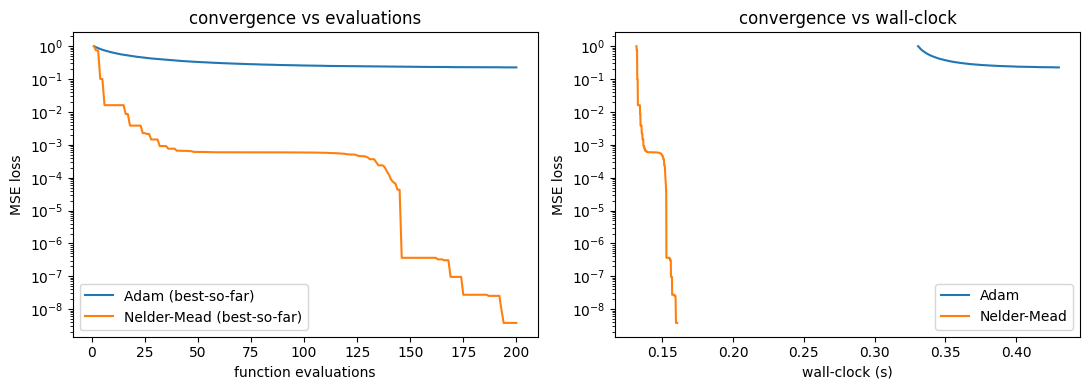

In [18]:
grad_best = np.minimum.accumulate(grad_loss)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(np.arange(1, len(grad_best) + 1), grad_best, label="Adam (best-so-far)", color="C0")
ax.plot(np.arange(1, len(nm_loss) + 1), nm_loss, label="Nelder-Mead (best-so-far)", color="C1")
ax.set_xlabel("function evaluations")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.set_title("convergence vs evaluations")
ax.legend()

ax = axes[1]
ax.plot(grad_cum_time, grad_best, label="Adam", color="C0")
ax.plot(nm_time, nm_loss, label="Nelder-Mead", color="C1")
ax.set_xlabel("wall-clock (s)")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.set_title("convergence vs wall-clock")
ax.legend()

plt.tight_layout(); plt.show()

In [19]:
grad_best_params = grad_result.get_params_dict()

print(f"{'param':<6} {'GT':>10} {'init':>10} {'Adam':>10} {'NM':>10}")
for n in TRAINABLE:
    print(f"{n:<6} {GT_PARAMS[n]:>10.3f} {init_params[n]:>10.3f} "
          f"{grad_best_params[n]:>10.3f} {nm_best_params[n]:>10.3f}")

param          GT       init       Adam         NM
C_m       200.000    210.634    239.662    210.154
g_L        10.000      8.738      6.060     10.591
E_L       -70.000    -65.000    -65.005    -69.520


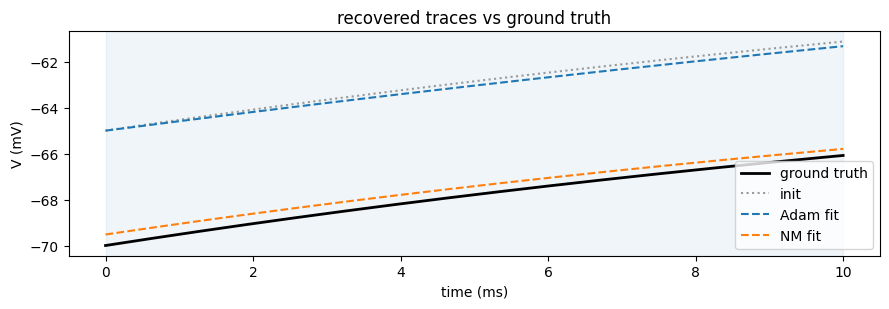

In [20]:
def sim_voltage(params):
    p = {**GT_PARAMS, **params}
    with _silence():
        s = simulate_jaxley(
            params=p, stim_current_pA=STIM_PA,
            stim_duration_ms=STIM_DUR_MS, dt_ms=DT_MS,
            t_max_ms=T_MAX_MS, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False,
        )
    return s.voltage


t = np.arange(len(gt_sim.voltage)) * DT_MS
v_init = sim_voltage(init_params)
v_grad = sim_voltage(grad_best_params)
v_nm = sim_voltage(nm_best_params)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t, gt_sim.voltage, color="k", lw=2, label="ground truth")
ax.plot(t[:len(v_init)], v_init, color="0.6", ls=":", label="init")
ax.plot(t[:len(v_grad)], v_grad, color="C0", ls="--", label="Adam fit")
ax.plot(t[:len(v_nm)], v_nm, color="C1", ls="--", label="NM fit")
ax.axvspan(STIM_DELAY_MS, STIM_DELAY_MS + STIM_DUR_MS, color="C0", alpha=0.07)
ax.set_xlabel("time (ms)"); ax.set_ylabel("V (mV)"); ax.set_title("recovered traces vs ground truth")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()